# Exploring Global Drinking Habits

*Investigation of alcohol consumption patterns across various countries by analyzing beer, wine, and spirit servings. It helps identify drinking trends, compare consumption levels between countries, and understand the contribution of different alcoholic beverages to overall alcohol intake*

IMPORTING LIBRARIES

In [81]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [82]:
df=pd.read_csv(r"C:\Users\muham\Downloads\beer-servings (1).csv")

Top 5 Rows Of Dataset

In [83]:
df.head(5)

,Unnamed: 0,country,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol,continent
0,0,Afghanistan,0.0,0.0,0.0,0.0,Asia
1,1,Albania,89.0,132.0,54.0,4.9,Europe
2,2,Algeria,25.0,0.0,14.0,0.7,Africa
3,3,Andorra,245.0,138.0,312.0,12.4,Europe
4,4,Angola,217.0,57.0,45.0,5.9,Africa


In [84]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 193 entries, 0 to 192
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Unnamed: 0                    193 non-null    int64  
 1   country                       193 non-null    str    
 2   beer_servings                 185 non-null    float64
 3   spirit_servings               185 non-null    float64
 4   wine_servings                 187 non-null    float64
 5   total_litres_of_pure_alcohol  192 non-null    float64
 6   continent                     193 non-null    str    
dtypes: float64(4), int64(1), str(2)
memory usage: 10.7 KB


In [85]:
df.describe()

,Unnamed: 0,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol
count,193.000000,185.000000,185.000000,187.000000,192.000000
mean,96.000000,105.124324,83.221622,50.165775,4.741667
std,55.858452,100.524714,89.142958,80.358868,3.767654
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,20.000000,4.000000,1.000000,1.300000
50%,96.000000,76.000000,60.000000,9.000000,4.250000
75%,144.000000,185.000000,132.000000,60.500000,7.200000
max,192.000000,376.000000,438.000000,370.000000,14.400000


In [86]:
df.shape

(193, 7)

In [87]:
df.duplicated().sum()

np.int64(0)

In [88]:
df.columns

Index(['Unnamed: 0', 'country', 'beer_servings', 'spirit_servings',
       'wine_servings', 'total_litres_of_pure_alcohol', 'continent'],
      dtype='str')

In [89]:
df=df.drop('Unnamed: 0',axis=1)

In [90]:
df

,country,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol,continent
0,Afghanistan,0.0,0.0,0.0,0.0,Asia
1,Albania,89.0,132.0,54.0,4.9,Europe
2,Algeria,25.0,0.0,14.0,0.7,Africa
3,Andorra,245.0,138.0,312.0,12.4,Europe
4,Angola,217.0,57.0,45.0,5.9,Africa
...,...,...,...,...,...,...
188,Venezuela,NaN,100.0,3.0,7.7,South America
189,Vietnam,111.0,2.0,1.0,2.0,Asia
190,Yemen,6.0,0.0,0.0,0.1,Asia
191,Zambia,32.0,19.0,4.0,2.5,Africa


# DATA PREPROCESSING

## Missing Value Handling:

In [91]:
df.isnull().sum()

country                         0
beer_servings                   8
spirit_servings                 8
wine_servings                   6
total_litres_of_pure_alcohol    1
continent                       0
dtype: int64

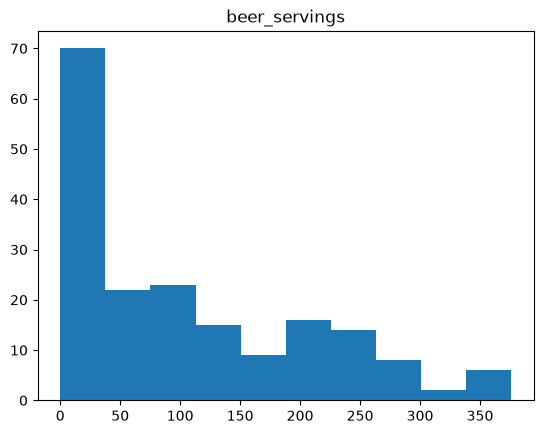

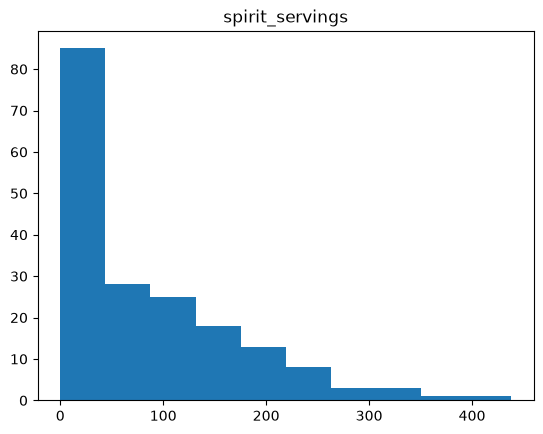

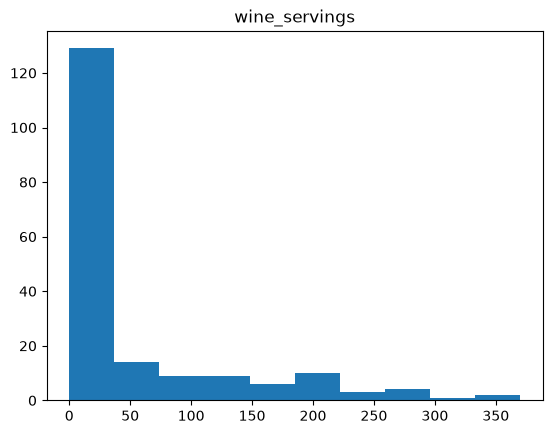

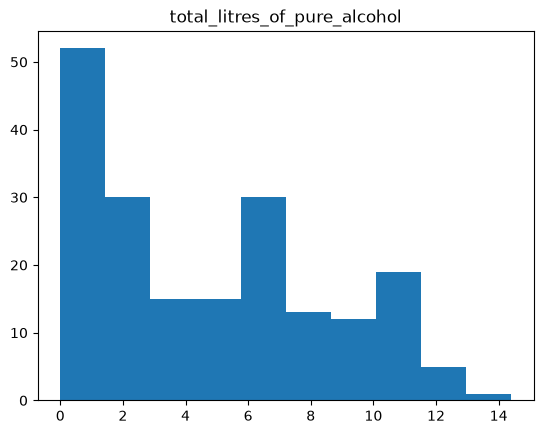

In [92]:
for i in ["beer_servings","spirit_servings","wine_servings","total_litres_of_pure_alcohol"]:
    plt.title(i)
    plt.hist(df[i])
    plt.show()

In [93]:
for i in ["beer_servings","spirit_servings","wine_servings","total_litres_of_pure_alcohol"]:
    df[i]=df[i].fillna(df[i].median())

In [94]:
df.isnull().sum()

country                         0
beer_servings                   0
spirit_servings                 0
wine_servings                   0
total_litres_of_pure_alcohol    0
continent                       0
dtype: int64

## Outlier Handling

<Axes: >

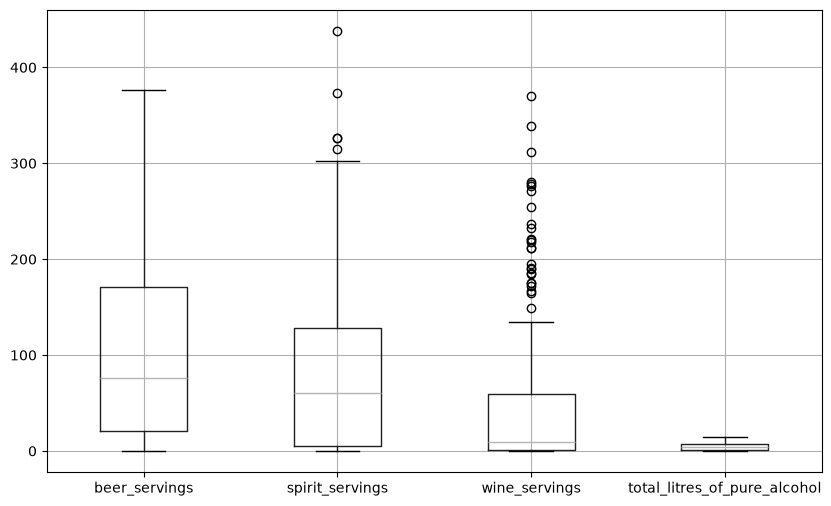

In [95]:
plt.figure(figsize=(10,6))
df.boxplot()

In [96]:
#Clipping Method
for i in ["wine_servings","spirit_servings"]:
    q1=df[i].quantile(0.25)
    q3=df[i].quantile(0.75)
    iqr=q3-q1
    lower=q1-1.5*iqr
    upper=q3+1.5*iqr
    df[i]=df[i].clip(lower,upper)

<Axes: >

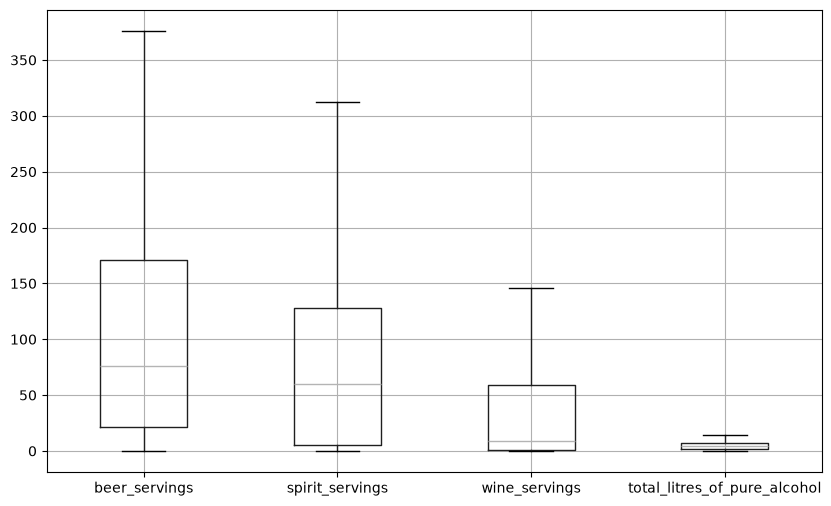

In [97]:
plt.figure(figsize=(10,6))
df.boxplot()

In [98]:
continent_average=df.groupby(["continent"])["total_litres_of_pure_alcohol"].mean()
continent_average

continent
Africa           3.007547
Asia             2.267045
Europe           8.617778
North America    5.995652
Oceania          3.381250
South America    6.308333
Name: total_litres_of_pure_alcohol, dtype: float64

Europe has the highest average pure alcohol consumption (8.62 litres per person), followed by South America (6.31 litres) and North America (6.00 litres). Asia shows the lowest average consumption (2.27 litres), indicating significant differences in alcohol consumption patterns across continents.

## Univariate Analysis

Text(0.5, 1.0, 'Distribution Of Alcohol')

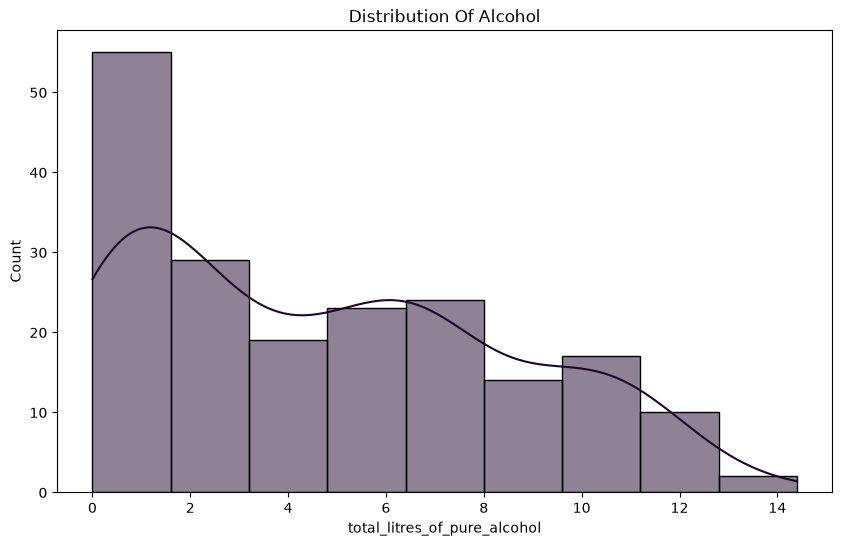

In [99]:
plt.figure(figsize=(10,6))
sns.histplot(df["total_litres_of_pure_alcohol"],kde=True,color="#1E072B")
plt.title("Distribution Of Alcohol")

The histogram shows that most countries consume low to moderate amounts of pure alcohol, as indicated by the higher bars on the left side of the distribution. The data is positively (right) skewed, meaning only a few countries have very high alcohol consumption levels. This suggests that high alcohol consumption is relatively uncommon compared to lower consumption levels.

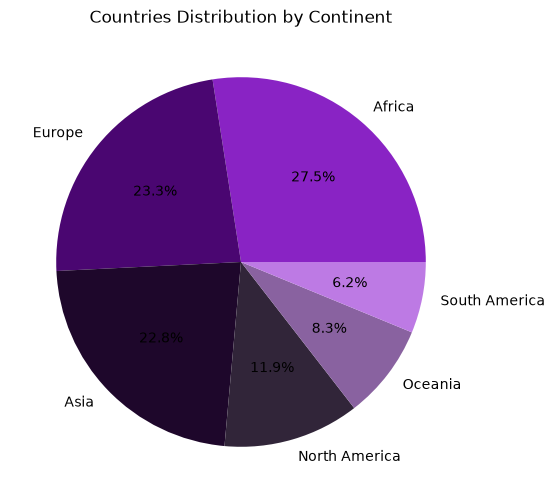

In [100]:
continent_counts = df['continent'].value_counts()
plt.figure(figsize=(10,6))
colors={"#1E072B","#312539","#8923C4","#4A0671","#BD7AE4","#8962A0"}
plt.pie(continent_counts,labels=continent_counts.index,autopct='%1.1f%%',colors=colors)
plt.title("Countries Distribution by Continent")
plt.show()

The pie chart shows that Africa (27.5%) and Asia (22.8%) account for the largest proportions of countries in the dataset, followed by Europe (23.3%). North America (11.9%), Oceania (8.3%), and South America (6.2%) contribute smaller shares. This indicates that the dataset has broad global coverage, with the highest representation from Africa, Asia, and Europe.

## Bivariate Analysis

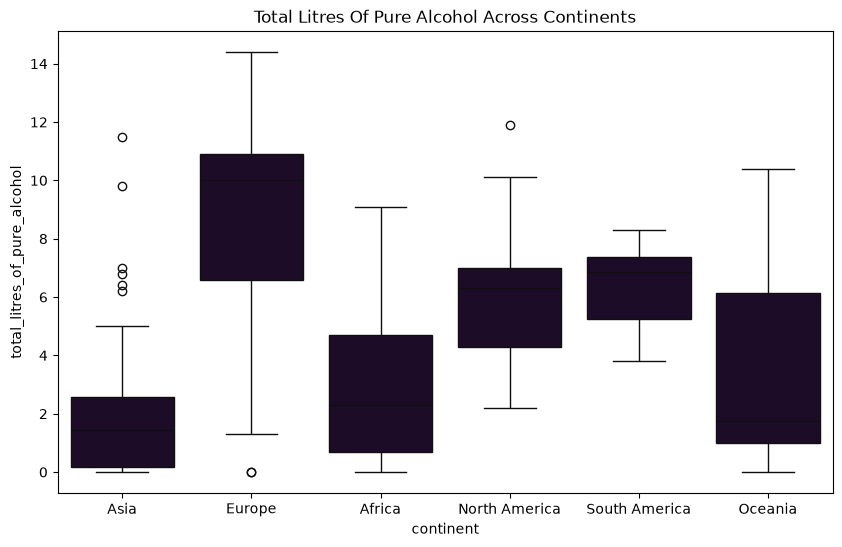

In [101]:
plt.figure(figsize=(10,6))
sns.boxplot(x='continent',y='total_litres_of_pure_alcohol',data=df,color="#1E072B")
plt.title("Total Litres Of Pure Alcohol Across Continents")
plt.show()

he boxplot shows that Europe has the highest median alcohol consumption and the greatest variability among countries. Africa and Asia have the lowest median consumption levels, while North America, South America, and Oceania exhibit moderate alcohol consumption patterns. Overall, alcohol consumption differs significantly across continents, with Europe standing out as the highest-consuming region.

Text(0.5, 1.0, 'Beer Servings VS Total Litres Of Pure Alcohol')

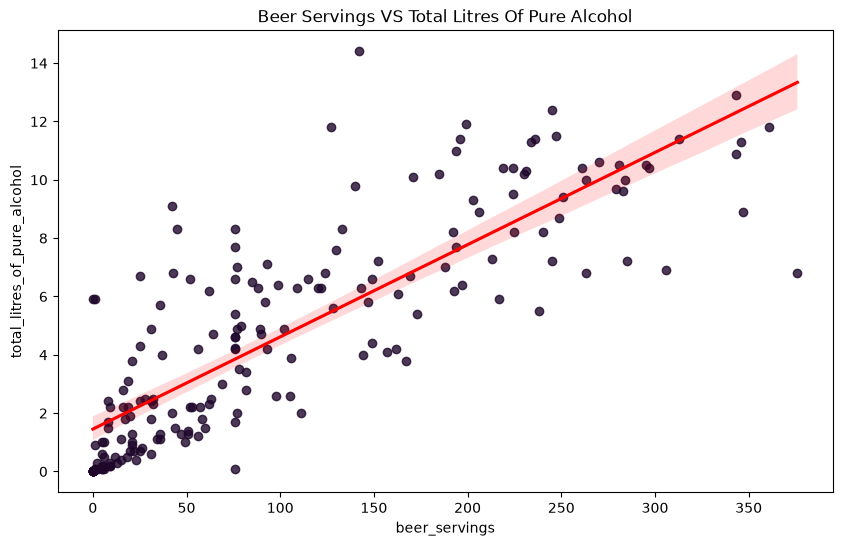

In [102]:
plt.figure(figsize=(10,6))
sns.regplot(x="beer_servings",y="total_litres_of_pure_alcohol",data=df,scatter_kws={"color":"#1E072B"},line_kws={"color":"Red"})
plt.title("Beer Servings VS Total Litres Of Pure Alcohol")

The boxplot shows that Europe has the highest median alcohol consumption and the greatest variability among countries. Africa and Asia have the lowest median consumption levels, while North America, South America, and Oceania exhibit moderate alcohol consumption patterns. Overall, alcohol consumption differs significantly across continents, with Europe standing out as the highest-consuming region.

Text(0.5, 1.0, 'Wine Servings VS Total Litres Of Pure Alcohol')

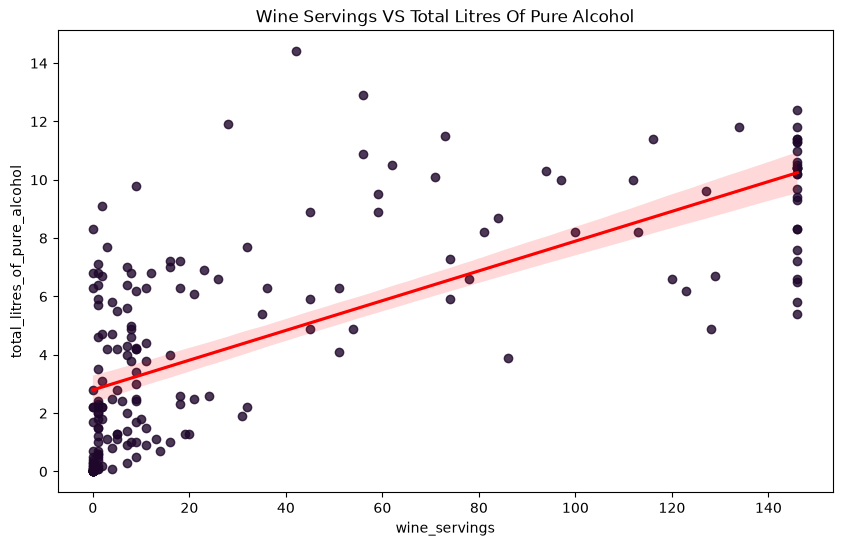

In [103]:
plt.figure(figsize=(10,6))
sns.regplot(x="wine_servings",y="total_litres_of_pure_alcohol",data=df,scatter_kws={"color":"#1E072B"},line_kws={"color":"Red"})
plt.title("Wine Servings VS Total Litres Of Pure Alcohol")

The scatter plot indicates a moderate positive relationship between wine servings and total litres of pure alcohol consumption. Countries with higher wine consumption generally tend to have higher overall alcohol consumption, although the data points are more dispersed compared to beer consumption, suggesting greater variation among countries.

Text(0.5, 1.0, 'Spir Servings VS Total Litres Of Pure Alcohol')

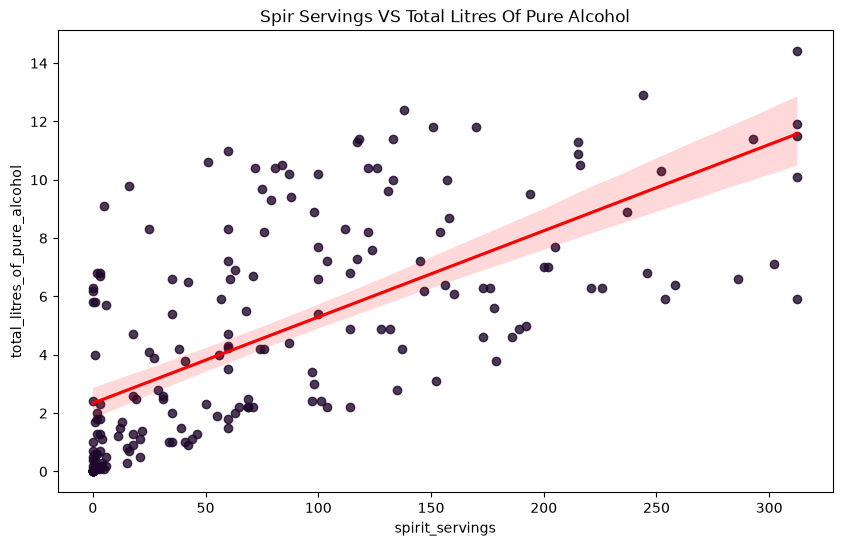

In [104]:
plt.figure(figsize=(10,6))
sns.regplot(x="spirit_servings",y="total_litres_of_pure_alcohol",data=df,scatter_kws={"color":"#1E072B"},line_kws={"color":"Red"})
plt.title("Spir Servings VS Total Litres Of Pure Alcohol")

The scatter plot shows a moderate positive relationship between spirit servings and total litres of pure alcohol consumption. Countries with higher spirit consumption generally tend to have higher overall alcohol consumption. However, the wide spread of data points indicates considerable variation among countries, suggesting that other factors also influence total alcohol consumption.

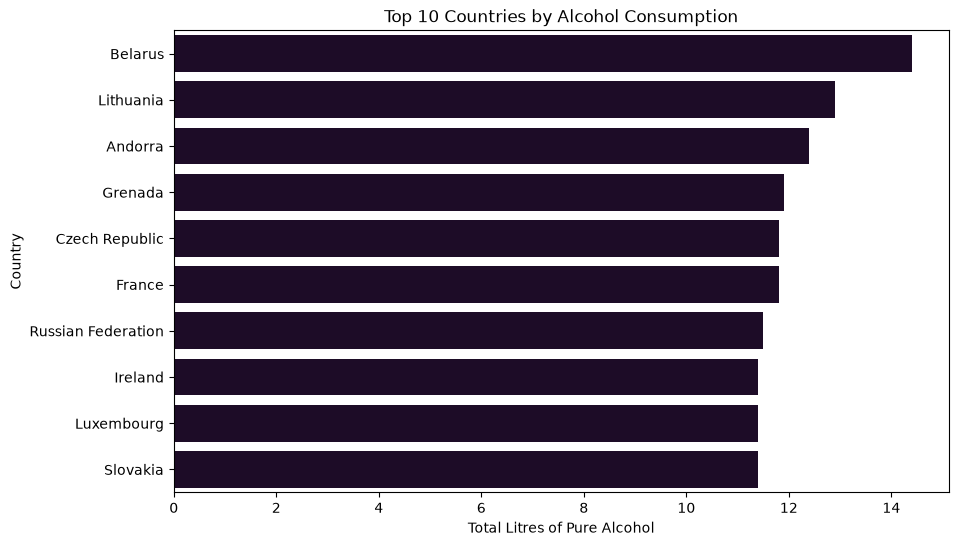

In [105]:
top10 = df.nlargest(10,'total_litres_of_pure_alcohol')
plt.figure(figsize=(10,6))
sns.barplot(x='total_litres_of_pure_alcohol',y='country',data=top10,color="#1E072B")
plt.title("Top 10 Countries by Alcohol Consumption")
plt.xlabel("Total Litres of Pure Alcohol")
plt.ylabel("Country")
plt.show()

The bar chart shows the top 10 countries with the highest alcohol consumption. Belarus has the highest consumption, followed by Lithuania and Andorra. Most of the top-consuming countries are European nations, indicating higher average alcohol intake in that region.

## Multivariate Analysis

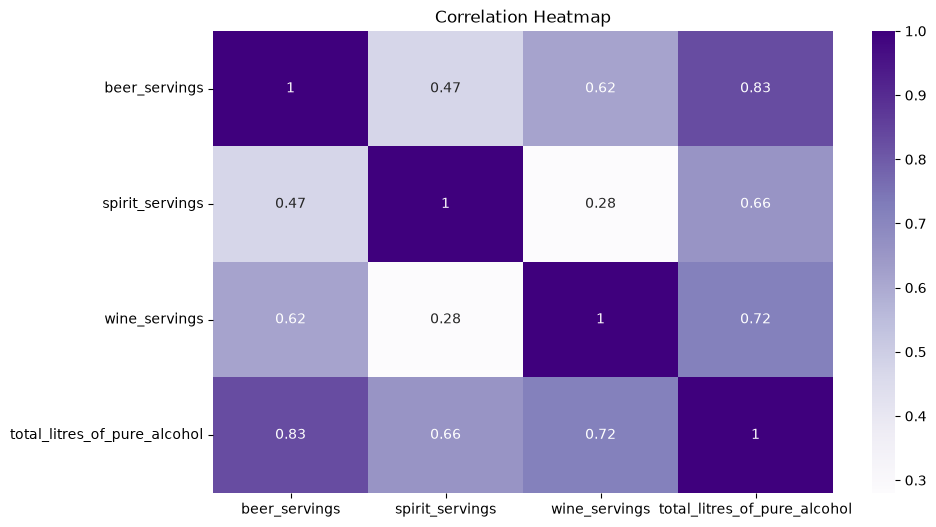

In [106]:
plt.figure(figsize=(10,6))
sns.heatmap(df.select_dtypes(include='number').corr(),annot=True,cmap="Purples")
plt.title("Correlation Heatmap")
plt.show()

The heatmap indicates that beer servings have the strongest relationship with total alcohol consumption (0.83), followed by wine servings (0.72) and spirit servings (0.66). Overall, higher beverage consumption is associated with higher total alcohol intake, with beer showing the strongest influence.